# Fine-tune ModernBERT-large for wine price regression

**Run this in Colab with a CUDA GPU.** ModernBERT-large is an encoder model, so this notebook fine-tunes
its sequence-classification head to predict `log1p(price)` from the tasting note. It is not a causal
language model: there is no prompt completion or number generation step.

The log target matches the project's primary RMSLE metric and prevents the expensive tail from
swamping the gradient. This run fully fine-tunes the 395M-parameter encoder and regression head;
ModernBERT-large fits comfortably on a high-memory GPU at this sequence length. Add `HF_TOKEN` and
`WANDB_API_KEY` as Colab secrets before running the setup cell.

In [ ]:
!pip install -q "transformers>=4.48.0" "datasets>=3.0" \
    "accelerate>=1.0" "wandb>=0.18" "scikit-learn>=1.5"
!git clone -q https://github.com/borjahernandez/wine-pricer.git
%cd wine-pricer

In [ ]:
import math
import os
from datetime import datetime

import numpy as np
import torch
import wandb
from datasets import load_dataset
from google.colab import userdata
from huggingface_hub import login
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

login(userdata.get("HF_TOKEN"))
os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY")
os.environ["WANDB_PROJECT"] = "wine-pricer"
os.environ["WANDB_LOG_MODEL"] = "false"
os.environ["WANDB_WATCH"] = "false"
wandb.login()

BASE_MODEL = "answerdotai/ModernBERT-large"
DATASET = "borjahernandez/wine-pricer"
RUN = "wine-pricer-modernbert-large"
RUN_NAME = f'{RUN}-{datetime.now():%Y%m%d-%H%M}'

### Prepare the regression dataset

The input is the exact stored inference prompt used by the Qwen notebook: the question, the same
truncated tasting note, and the `Price is $` prefix. Metadata such as `points`, country, and winery
stays out of the input. This makes both models read the same 250 test examples in the same format. The
label is `log1p(price)`; predictions are converted back with `expm1` for reporting.

In [ ]:
data = load_dataset(DATASET)


def add_label(row):
    return {
        "text": row["prompt"].split("Price is $")[0] + "Price is $",
        "labels": np.float32(np.log1p(row["price"])),
    }


encoded = data.map(add_label, remove_columns=data["train"].column_names)
print(encoded)
print(encoded["train"][0])

MAX_LENGTH = 256  # match the Qwen fine-tune's context budget
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)


def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)


tokenized = encoded.map(tokenize, batched=True, remove_columns=["text"])
print(tokenized["train"].column_names)

In [ ]:
NUM_EPOCHS = 2
PER_DEVICE_BATCH_SIZE = 16
GRADIENT_ACCUMULATION_STEPS = 1
EFFECTIVE_BATCH_SIZE = PER_DEVICE_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
STEPS = math.ceil(len(tokenized["train"]) / EFFECTIVE_BATCH_SIZE) * NUM_EPOCHS

ARGS = TrainingArguments(
    output_dir=RUN,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    gradient_checkpointing=True,
    learning_rate=2e-5,
    lr_scheduler_type="cosine",
    warmup_steps=int(0.03 * STEPS),  # 3% of this run, regardless of dataset size
    weight_decay=0.01,
    eval_strategy="steps",
    eval_steps=500,
    save_steps=500,
    save_total_limit=2,
    logging_steps=50,
    report_to="wandb",
    run_name=RUN_NAME,
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),
    load_best_model_at_end=True,
    metric_for_best_model="rmsle",
    greater_is_better=False,
    push_to_hub=True,
    hub_model_id=f"borjahernandez/{RUN}",
    hub_private_repo=True,
)


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.asarray(predictions).reshape(-1)
    labels = np.asarray(labels).reshape(-1)
    return {
        "rmsle": float(np.sqrt(np.mean((predictions - labels) ** 2))),
        "mae_dollars": float(np.mean(np.abs(np.expm1(predictions) - np.expm1(labels)))),
    }


model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=1,
    problem_type="regression",
)
model.config.pad_token_id = tokenizer.pad_token_id
trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f"trainable parameters: {trainable:,}")

trainer = Trainer(
    model=model,
    args=ARGS,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)
trainer.train()
trainer.evaluate()
trainer.push_to_hub(f"Fine-tuned {BASE_MODEL} on {DATASET}")
wandb.finish()

### Evaluate on the shared test split

This calls the same evaluator used by the classical models and the causal-language-model notebook.
The reported RMSLE is directly comparable because the model predicts in log space and is converted back
only at the evaluation boundary.

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


config.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.58M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.58GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/174 [00:00<?, ?it/s]

num_labels=1, problem_type=regression


Modernbert-Large (Full Ft):   0%|          | 0/2000 [00:00<?, ?it/s]

Modernbert-Large (Full Ft): MAE $12.43 | RMSLE 0.367 | R2 62.2% | hits 67.5%


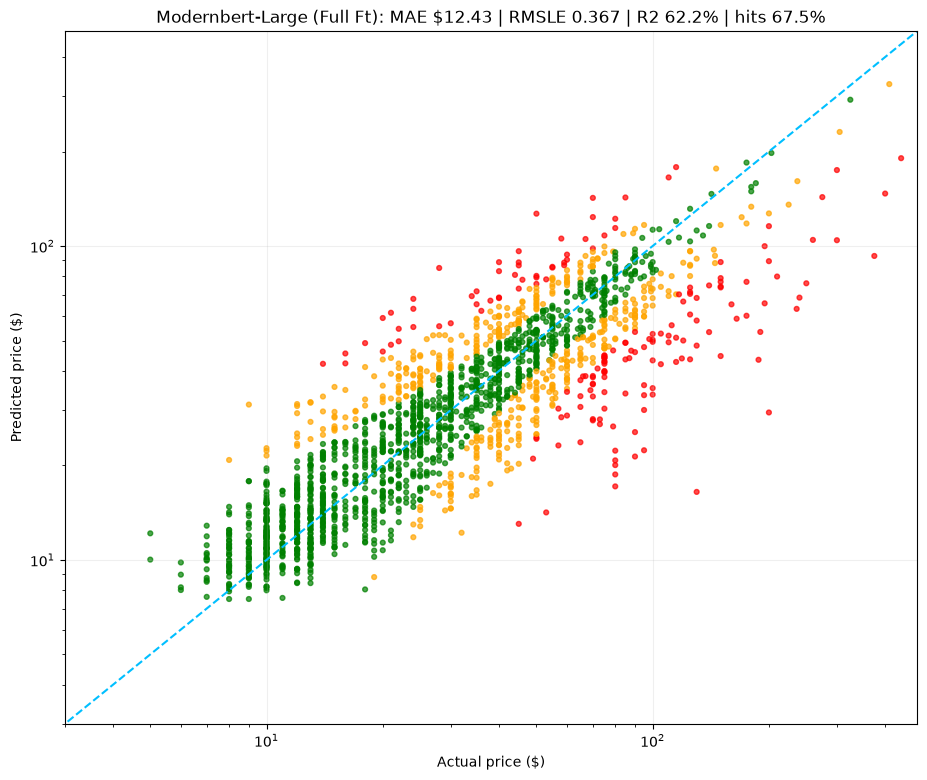

model                                    MAE    RMSLE      R2    hits      n
Modernbert-Large (Full Ft)            12.43    0.367   62.2%   67.5%  2,000
Claude Opus 5                         13.31    0.390   45.3%   64.4%  2,000
Tf-Idf + Ridge                        15.31    0.454   44.4%   58.9%  2,000
Lsa + Random Forest                   16.57    0.505   34.1%   55.1%  2,000
Classical (note only)                 16.38    0.518   39.0%   57.0%    100
Metadata + Linear Regression          17.40    0.532   29.2%   52.8%  2,000
Neighbours (k=8, retrieval only)      18.49    0.554   32.4%   49.0%    100
Frontier (RAG + LLM)                  20.74    0.639   29.8%   46.0%    100
Constant $30                          23.96    0.749   -7.7%   29.6%  2,000


In [2]:
import os

import numpy as np
import torch
from dotenv import load_dotenv
from huggingface_hub import login
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from pricer.evaluator import evaluate, leaderboard
from pricer.items import Wine

load_dotenv(override=True)
login(os.environ["HF_TOKEN"])        # the repo is private

DATASET = "borjahernandez/wine-pricer"
FINETUNED = "borjahernandez/wine-pricer-wine-pricer-modernbert-large-full-20260905-1229"

MAX_LENGTH = 256                          # same as training and as the Qwen evaluation
MAX_LOG_PRICE = float(np.log1p(1000))

# Full fine-tune, so the Hub repo holds complete weights -- no base model, no adapter merge.
tokenizer = AutoTokenizer.from_pretrained(FINETUNED)
model = AutoModelForSequenceClassification.from_pretrained(FINETUNED)
model.to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

print(f"num_labels={model.config.num_labels}, problem_type={model.config.problem_type}")

_, _, test = Wine.from_hub(DATASET)


def specialist(wine: Wine) -> float:
    inputs = tokenizer(
        wine.test_prompt(), return_tensors="pt", truncation=True, max_length=MAX_LENGTH
    ).to(model.device)
    with torch.no_grad():
        log_price = model(**inputs).logits.squeeze().item()
    return float(np.expm1(min(max(log_price, 0.0), MAX_LOG_PRICE)))


specialist.__name__ = "ModernBERT-large (full FT)"
evaluate(specialist, test, size=len(test))
leaderboard()

### Experiments

- Compare `r=8`, `r=16`, and full fine-tuning at matched steps.
- Increase `MAX_LENGTH` to test whether long tasting notes contain useful signal.
- Train on `summary` instead of `full` using the summaries dataset.
- Add `points` deliberately as a leakage experiment, then compare the RMSLE gap.